<a href="https://colab.research.google.com/github/trisha-fernandes/Data-Analysis-Python/blob/main/PythonPortfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --quiet google-cloud-bigquery pandas-gbq

In [2]:
from google.colab import auth
auth.authenticate_user()

In [3]:
from google.cloud import bigquery

client = bigquery.Client(
    project="thelook-ecommerce-sql-analysis"
)

In [17]:
query = """
SELECT *
FROM `thelook-ecommerce-sql-analysis.portfolio.sales_master`
"""

df = client.query(query).to_dataframe()

print(df.shape)
df.head()

(174878, 23)


,orderitem_id,order_id,user_id,product_id,order_month,order_quarter,order_year,year_month,sale_price,status,...,gender,age,city,country,age_group,category,brand,name,cost,profit
0,70707,48650,38764,13726,3,1,2021,2021-03,9.00,Shipped,...,F,28,Hangzhou,China,25-34,Accessories,Funny Girl Designs,(Set of 3) Leopard Animal Print Stretch Headband,3.58200,5.41800
1,124687,85814,68505,14106,6,2,2021,2021-06,10.99,Cancelled,...,F,28,Glasgow,United Kingdom,25-34,Accessories,Funny Girl Designs,(Set of 4) 2.5 Glitter Cotton Stretch Headbands,4.11026,6.87974
2,70442,48464,38624,29070,8,3,2021,2021-08,17.99,Returned,...,M,35,Praia Grande,Brasil,35-44,Accessories,TheTieBar,100% Silk Woven Brown Lavender and Rust Hendri...,7.53781,10.45219
3,105443,72551,57897,28649,5,2,2021,2021-05,15.99,Complete,...,M,53,Shanghai,China,45+,Accessories,TheTieBar,100% Silk Woven Charcoal Paisley Tie,6.34803,9.64197
4,12434,8495,6650,28604,2,1,2021,2021-02,17.99,Complete,...,M,68,Beijing,China,45+,Accessories,TheTieBar,100% Silk Woven Colorful Gingham Blue and Gray...,6.89017,11.09983


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174878 entries, 0 to 174877
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   orderitem_id   174878 non-null  Int64              
 1   order_id       174878 non-null  Int64              
 2   user_id        174878 non-null  Int64              
 3   product_id     174878 non-null  Int64              
 4   order_month    174878 non-null  Int64              
 5   order_quarter  174878 non-null  Int64              
 6   order_year     174878 non-null  Int64              
 7   year_month     174878 non-null  object             
 8   sale_price     174878 non-null  float64            
 9   status         174878 non-null  object             
 10  created_at     174878 non-null  datetime64[us, UTC]
 11  delivered_at   60986 non-null   datetime64[us, UTC]
 12  returned_at    17169 non-null   datetime64[us, UTC]
 13  gender         174878 non-nul

In [19]:
df.describe()

,orderitem_id,order_id,user_id,product_id,order_month,order_quarter,order_year,sale_price,age,cost,profit
count,174878.0,174878.0,174878.0,174878.0,174878.0,174878.0,174878.0,174878.000000,174878.0,174878.000000,174878.000000
mean,90898.634168,62566.999274,49922.207962,15290.959823,6.17885,2.379287,2024.330585,59.581974,40.928453,28.655313,30.926660
std,52452.926433,36116.05008,28909.005329,8409.488564,3.372029,1.092583,1.481127,65.860597,17.039353,30.616103,36.239564
min,1.0,1.0,1.0,1.0,1.0,1.0,2021.0,0.020000,12.0,0.008300,0.011700
25%,45521.25,31317.25,24871.0,8026.0,3.0,1.0,2023.0,24.559999,26.0,11.374000,11.712105
50%,90843.5,62519.5,49896.5,16023.0,6.0,2.0,2025.0,39.990002,41.0,19.816650,20.131200
75%,136351.75,93802.75,74958.75,22549.0,9.0,3.0,2026.0,69.949997,56.0,34.606567,35.974859
max,181775.0,125203.0,99999.0,29120.0,12.0,4.0,2026.0,999.000000,70.0,557.151002,594.404999


In [20]:
df.isnull().sum()

,0
orderitem_id,0
order_id,0
user_id,0
product_id,0
order_month,0
order_quarter,0
order_year,0
year_month,0
sale_price,0
status,0


In [21]:
df["sale_price"].sum()

np.float64(10419576.390506893)

In [22]:
# Monthly Revenue
import pandas as pd

df["created_at"] = pd.to_datetime(
    df["created_at"]
)

monthly_revenue = (
    df.groupby(
        df["created_at"]
        .dt.to_period("M")
    )["sale_price"]
    .sum()
)

monthly_revenue.head()

/tmp/ipykernel_21874/3960336666.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,sale_price
created_at,
2021-01,40516.890101
2021-02,39641.370072
2021-03,40299.569982
2021-04,45017.950085
2021-05,44056.460042


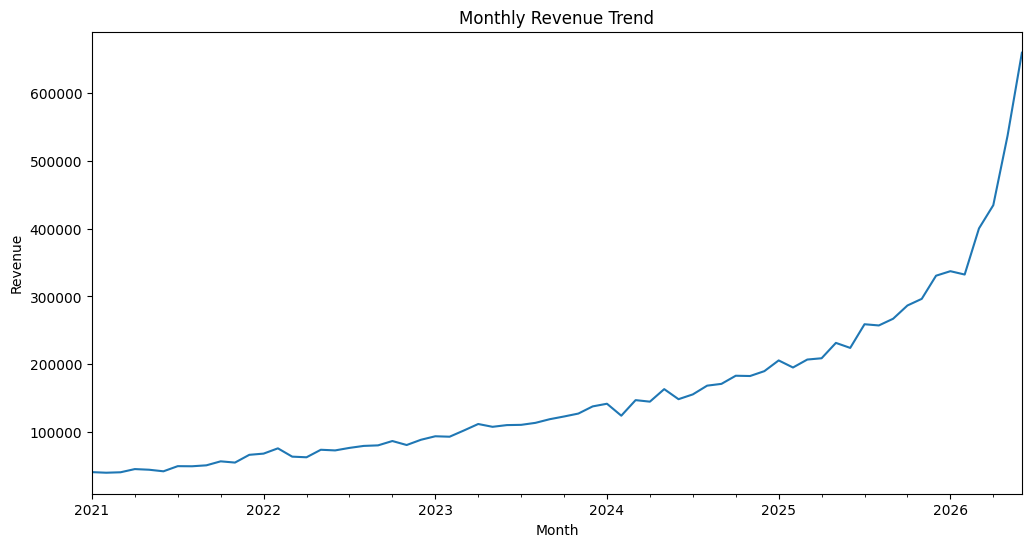

In [23]:
# Plot Revenue Trend
import matplotlib.pyplot as plt

monthly_revenue.plot(figsize=(12,6))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [24]:
# Top Categories
category_sales = (
    df.groupby("category")
      ["sale_price"]
      .sum()
      .sort_values(
          ascending=False
      )
)

category_sales.head(10)

,sale_price
category,
Outerwear & Coats,1.242605e+06
Jeans,1.205791e+06
Sweaters,8.129709e+05
Suits & Sport Coats,6.543503e+05
Swim,6.250318e+05
Fashion Hoodies & Sweatshirts,6.178246e+05
Sleep & Lounge,5.346577e+05
Shorts,4.890933e+05
Tops & Tees,4.714606e+05


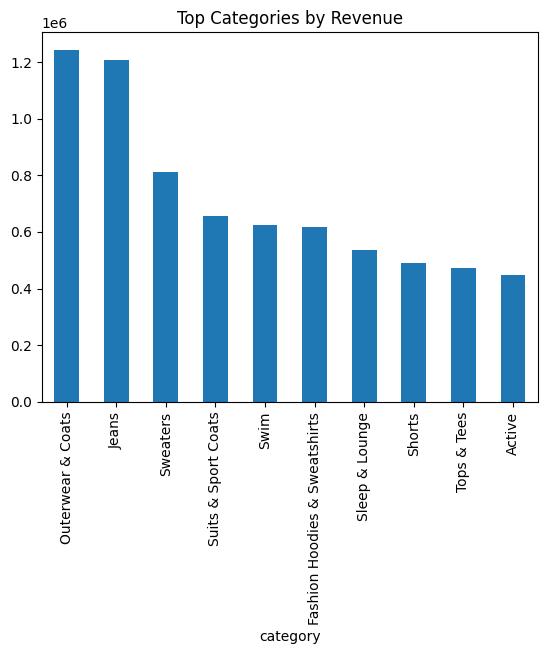

In [25]:
category_sales.head(10).plot.bar()
plt.title("Top Categories by Revenue")
plt.show()

In [26]:
# Customer Analysis
customer_sales = (
    df.groupby("user_id")
      ["sale_price"]
      .sum()
      .sort_values(
          ascending=False
      )
)

customer_sales.head(10)

,sale_price
user_id,
49207,2051.839985
84945,1764.689987
18337,1618.580002
70493,1600.660000
5471,1592.480003
77700,1542.040001
83057,1531.510002
70363,1457.389996
18570,1447.570004


In [27]:
# Customer Segmentation
customer_revenue = (
    df.groupby("user_id")
      ["sale_price"]
      .sum()
      .reset_index()
)

customer_revenue["segment"] = pd.cut(
    customer_revenue["sale_price"],
    bins=[0,100,500,1000,100000],
    labels=[
        "Low",
        "Medium",
        "High",
        "VIP"
    ]
)

customer_revenue.head()

,user_id,sale_price,segment
0,1,296.940006,Medium
1,2,9.950000,Low
2,3,288.920000,Medium
3,4,28.799999,Low
4,5,107.900000,Medium
